In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

Dataset Shape: (284807, 31)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage: 0.1727%


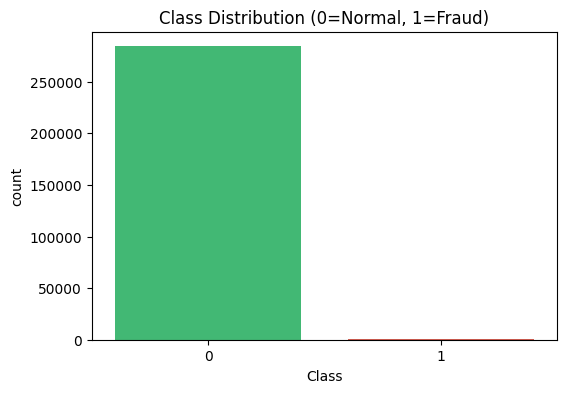

In [ ]:
# Load dataset
df = pd.read_csv('/content/creditcard.csv')

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud Percentage: {df['Class'].mean()*100:.4f}%")

# Visualize class imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Class Distribution (0=Normal, 1=Fraud)')
plt.savefig('class_distribution.png')
plt.show()

In [ ]:
# Scale 'Amount' and 'Time'
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])
df.drop(['Amount', 'Time'], axis=1, inplace=True)

# Split features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle class imbalance using SMOTE-like oversampling
X_train_combined = pd.concat([X_train, y_train], axis=1)
fraud = X_train_combined[X_train_combined.Class == 1]
normal = X_train_combined[X_train_combined.Class == 0]

fraud_upsampled = resample(fraud, replace=True,
                            n_samples=len(normal), random_state=42)
upsampled = pd.concat([normal, fraud_upsampled])

X_train_bal = upsampled.drop('Class', axis=1)
y_train_bal = upsampled['Class']

print(f"Balanced Training Set: {y_train_bal.value_counts().to_dict()}")

Balanced Training Set: {0: 227451, 1: 227451}


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'auc': auc, 'pred': y_pred, 'prob': y_prob}

    print(f"✅ {name} — ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))


🔄 Training Logistic Regression...
✅ Logistic Regression — ROC-AUC: 0.9720
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


🔄 Training Random Forest...
✅ Random Forest — ROC-AUC: 0.9527
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.95      0.78      0.85        98

    accuracy                           1.00     56962
   macro avg       0.97      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
print("🔄 Training Isolation Forest (Unsupervised)...")
iso_forest = IsolationForest(contamination=0.002, random_state=42, n_jobs=-1)
iso_pred = iso_forest.fit_predict(X_test)
iso_pred_binary = [1 if x == -1 else 0 for x in iso_pred]

iso_auc = roc_auc_score(y_test, iso_pred_binary)
print(f"✅ Isolation Forest — ROC-AUC: {iso_auc:.4f}")
print(classification_report(y_test, iso_pred_binary, target_names=['Normal', 'Fraud']))

🔄 Training Isolation Forest (Unsupervised)...
✅ Isolation Forest — ROC-AUC: 0.6625
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.28      0.33      0.30        98

    accuracy                           1.00     56962
   macro avg       0.64      0.66      0.65     56962
weighted avg       1.00      1.00      1.00     56962



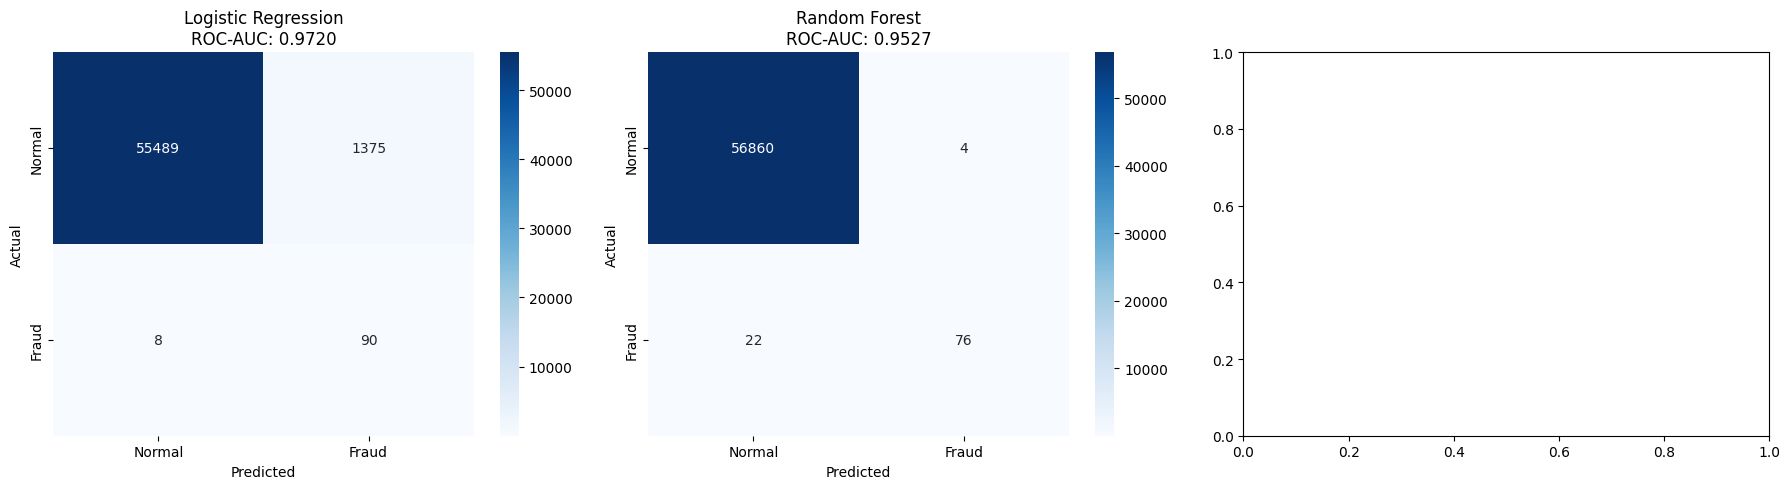

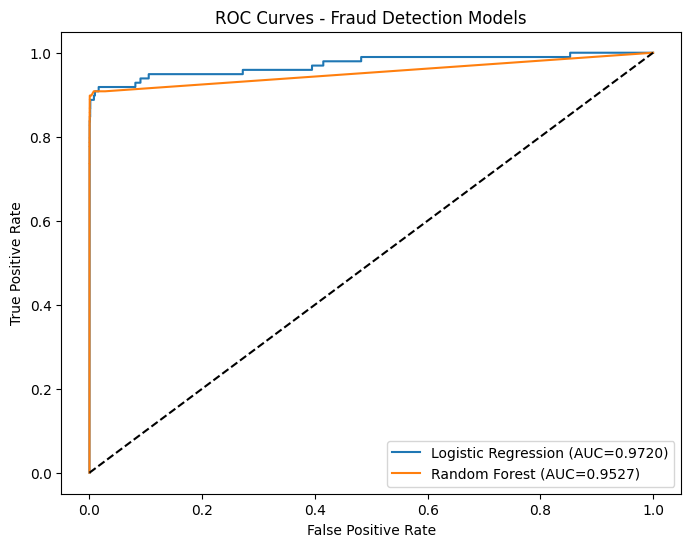

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, result) in enumerate(results.items()):
    # Confusion Matrix
    cm = confusion_matrix(y_test, result['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Normal','Fraud'], yticklabels=['Normal','Fraud'])
    axes[idx].set_title(f'{name}\nROC-AUC: {result["auc"]:.4f}')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={result['auc']:.4f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Fraud Detection Models')
plt.legend()
plt.savefig('roc_curves.png')
plt.show()

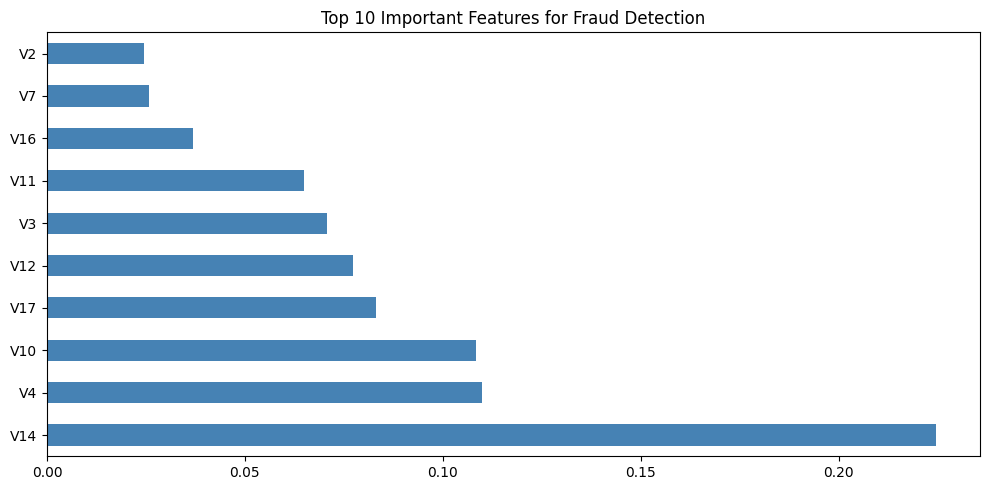

Status: ✅ LEGITIMATE
Fraud Probability: 0.0000 (0.00%)
✅ Action: Approve transaction


(np.int64(0), np.float64(0.0))

In [ ]:
# Feature Importance (Random Forest)
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.nlargest(10)

plt.figure(figsize=(10, 5))
top_features.plot(kind='barh', color='steelblue')
plt.title('Top 10 Important Features for Fraud Detection')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# Real-Time Prediction Function
def predict_transaction(transaction_data, model=rf_model):
    """
    Simulates real-time fraud detection on a single transaction.
    transaction_data: dict or array of feature values
    """
    if isinstance(transaction_data, dict):
        transaction_data = pd.DataFrame([transaction_data])

    prediction = model.predict(transaction_data)[0]
    probability = model.predict_proba(transaction_data)[0][1]

    status = "🚨 FRAUD DETECTED" if prediction == 1 else "✅ LEGITIMATE"
    print(f"Status: {status}")
    print(f"Fraud Probability: {probability:.4f} ({probability*100:.2f}%)")

    if probability > 0.7:
        print("⚠️ Action: BLOCK transaction immediately & alert user")
    elif probability > 0.3:
        print("⚠️ Action: FLAG for manual review")
    else:
        print("✅ Action: Approve transaction")

    return prediction, probability

# Test with a sample transaction
sample = X_test.iloc[0:1]
predict_transaction(sample)

In [ ]:
import joblib
joblib.dump(rf_model, '/content/fraud_detection_model.pkl')
print("✅ Model saved!")

✅ Model saved!
